<a href="https://colab.research.google.com/github/vimi100/CyberSystem/blob/main/classification_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование моделей классификации для диагностики болезни Альцгеймера
### Выполнил студент М8О-406Б-22 Бурунов М.А.
## Часть 1. Выбор начальных условий

В этом ноутбуке выполняется лабораторная работа по варианту задания на `5`: **проведение исследований с моделями классификации**.

Выбранный набор данных: `uraninjo/augmented-alzheimer-mri-dataset`.

Практическая постановка задачи: по MRI-снимку головного мозга определить стадию когнитивных нарушений. Такая задача важна как вспомогательный инструмент для медицинского анализа, раннего выявления заболевания и поддержки принятия решений врачом.

В наборе данных используются 4 класса:
- `Non Demented`
- `Very Mild Demented`
- `Mild Demented`
- `Moderate Demented`

Почему выбран этот датасет:
- задача имеет прикладную медицинскую значимость;
- датасет подходит именно для **классификации изображений**;
- количество классов больше двух, поэтому можно провести полноценное сравнение моделей;
- набор удобно подключать в Google Colab через Kaggle API.

В качестве основных метрик качества будут использоваться:
- `Accuracy` — показывает общую долю верно классифицированных изображений;
- `Macro F1-score` — важна для многоклассовой задачи, так как усредняет качество по всем классам и меньше зависит от дисбаланса;
- `Confusion Matrix` — позволяет увидеть, какие стадии заболевания модель чаще всего путает между собой.

Почему выбраны именно эти метрики:
- одной `Accuracy` недостаточно, если классы распределены неравномерно;
- `Macro F1-score` лучше отражает качество на редких классах;
- матрица ошибок дает интерпретируемый медицинский анализ ошибок модели.


In [1]:
!pip install -q kaggle

## Часть 2. Подключение датасета через Kaggle API

Для работы в `Google Colab` необходимо загрузить файл `kaggle.json` со своим API-ключом Kaggle.

Как получить ключ:
- открыть сайт Kaggle;
- перейти в раздел `Account`;
- нажать `Create New API Token`;
- загрузить файл `kaggle.json` в Colab.


In [2]:
from google.colab import files
import os

uploaded = files.upload()  # загрузите kaggle.json

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print('Kaggle API настроен.')

Saving kaggle.json to kaggle.json
Kaggle API настроен.


In [3]:
DATASET = 'uraninjo/augmented-alzheimer-mri-dataset'
DOWNLOAD_DIR = '/content/data'

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d $DATASET -p $DOWNLOAD_DIR --unzip

Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100% 380M/380M [00:27<00:00, 14.5MB/s]



In [4]:
from pathlib import Path
from collections import Counter

root = Path('/content/data')
image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}

image_files = [p for p in root.rglob('*') if p.suffix.lower() in image_exts]
class_counts = Counter()

for path in image_files:
    rel_parts = path.relative_to(root).parts
    if len(rel_parts) >= 2:
        class_counts[rel_parts[0]] += 1

print(f'Всего изображений: {len(image_files)}')
print('\nКоличество изображений по классам:')
for class_name, count in sorted(class_counts.items()):
    print(f'{class_name}: {count}')

Всего изображений: 40384

Количество изображений по классам:
AugmentedAlzheimerDataset: 33984
OriginalDataset: 6400


## Часть 3. Первичный анализ структуры датасета

После загрузки датасета необходимо проверить его структуру: где именно находятся изображения и как распределены данные по классам.

Это важно по двум причинам:
- нужно правильно указать путь к корневой папке с изображениями;
- нужно заранее понять, есть ли дисбаланс между классами.

На этом этапе мы:
- найдем папку, в которой лежат классы;
- выведем названия классов;
- посчитаем количество изображений в каждом классе.


In [5]:
from pathlib import Path
from collections import Counter

DATA_ROOT = Path("/content/data")
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_images_in_dir(path: Path):
    return len([p for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTS])

# Ищем директорию, внутри которой лежат папки-классы с изображениями
candidate_roots = []

for directory in DATA_ROOT.rglob("*"):
    if directory.is_dir():
        subdirs = [d for d in directory.iterdir() if d.is_dir()]
        if not subdirs:
            continue

        image_counts = {d.name: count_images_in_dir(d) for d in subdirs}
        non_empty_subdirs = {name: cnt for name, cnt in image_counts.items() if cnt > 0}

        # Считаем кандидатом директорию, если у нее хотя бы 2 непустые подпапки
        if len(non_empty_subdirs) >= 2:
            candidate_roots.append((directory, non_empty_subdirs))

print("Найденные кандидаты на корневую папку с классами:\n")
for idx, (root_dir, counts) in enumerate(candidate_roots, 1):
    print(f"{idx}. {root_dir}")
    for class_name, count in sorted(counts.items()):
        print(f"   {class_name}: {count}")
    print()

# Берем самый подходящий кандидат: с максимальным числом непустых классов
best_root, best_counts = max(candidate_roots, key=lambda x: len(x[1]))

print("=" * 60)
print(f"Выбранная корневая папка датасета: {best_root}")
print("Классы и количество изображений:")
for class_name, count in sorted(best_counts.items()):
    print(f"{class_name}: {count}")

CLASS_NAMES = sorted(best_counts.keys())
DATASET_DIR = best_root

print("\nСписок классов:")
print(CLASS_NAMES)


Найденные кандидаты на корневую папку с классами:

1. /content/data/OriginalDataset
   MildDemented: 896
   ModerateDemented: 64
   NonDemented: 3200
   VeryMildDemented: 2240

2. /content/data/AugmentedAlzheimerDataset
   MildDemented: 8960
   ModerateDemented: 6464
   NonDemented: 9600
   VeryMildDemented: 8960

Выбранная корневая папка датасета: /content/data/OriginalDataset
Классы и количество изображений:
MildDemented: 896
ModerateDemented: 64
NonDemented: 3200
VeryMildDemented: 2240

Список классов:
['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


## Часть 4. Визуальная проверка изображений

Перед обучением модели полезно визуально проверить данные. Это помогает убедиться, что:
- изображения действительно читаются корректно;
- классы распределены по папкам правильно;
- в данных нет очевидных ошибок или поврежденных файлов.

Ниже выводятся случайные примеры изображений из каждого класса.


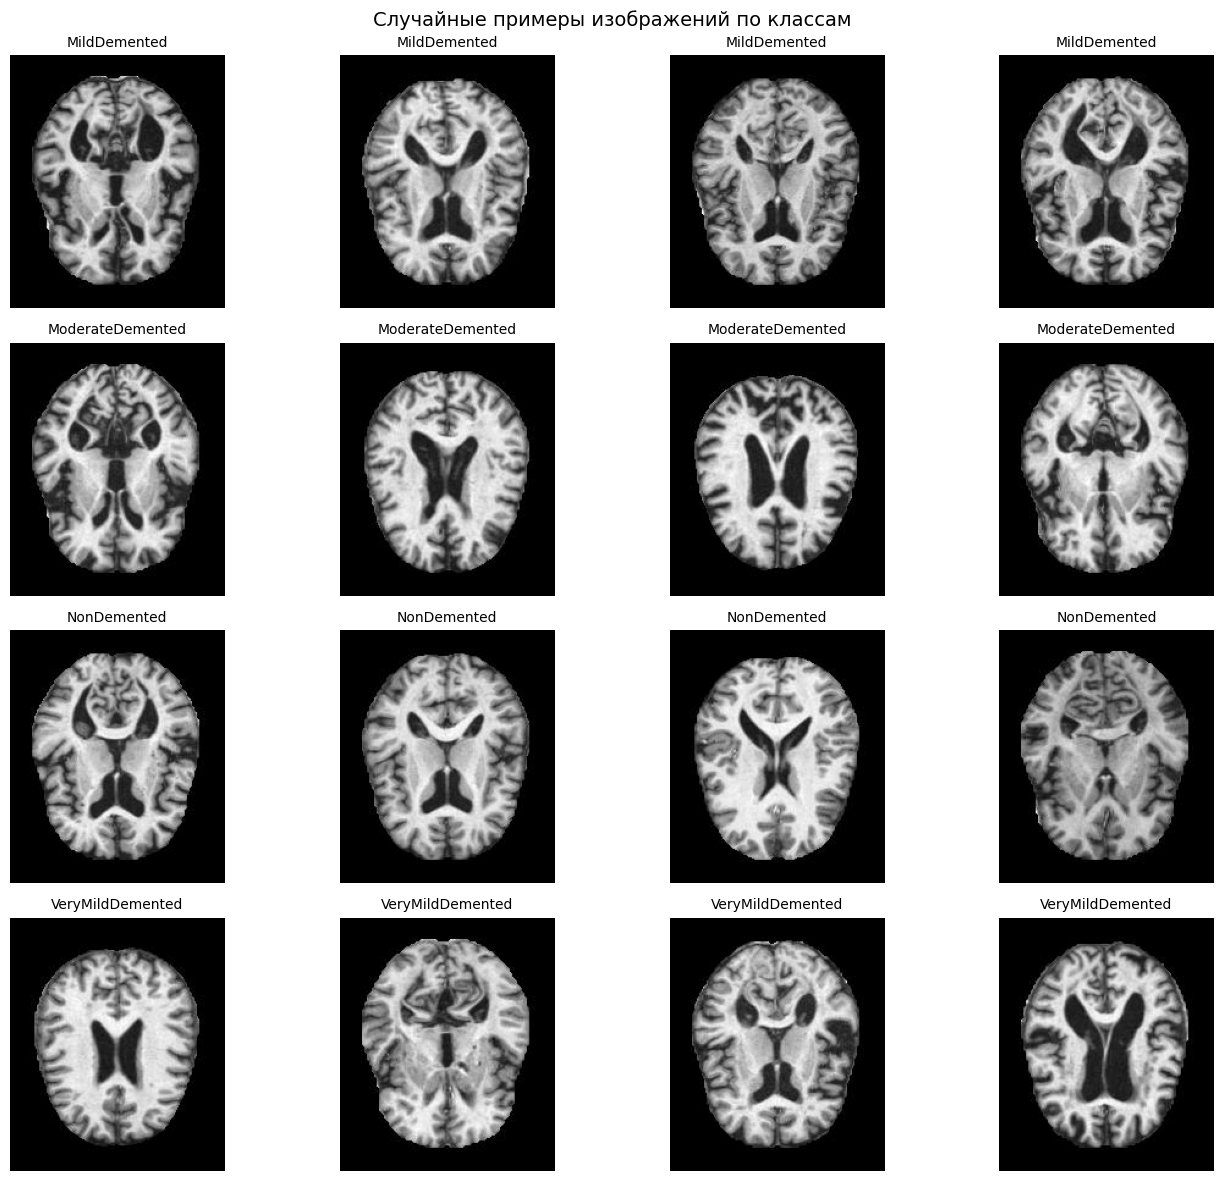

In [6]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

samples_per_class = 4
fig, axes = plt.subplots(len(CLASS_NAMES), samples_per_class, figsize=(14, 12))

for row, class_name in enumerate(CLASS_NAMES):
    class_dir = DATASET_DIR / class_name
    image_paths = [p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    sampled_paths = random.sample(image_paths, k=min(samples_per_class, len(image_paths)))

    for col in range(samples_per_class):
        ax = axes[row, col]

        if col < len(sampled_paths):
            img = Image.open(sampled_paths[col]).convert("L")  # MRI обычно одноканальные
            ax.imshow(img, cmap="gray")
            ax.set_title(class_name, fontsize=10)
        else:
            ax.axis("off")
            continue

        ax.axis("off")

plt.suptitle("Случайные примеры изображений по классам", fontsize=14)
plt.tight_layout()
plt.show()


## Часть 5. Разделение данных на train / validation / test

Для корректного сравнения моделей датасет нужно разделить на три части:
- `train` — для обучения модели;
- `validation` — для подбора гиперпараметров и выбора лучшей версии;
- `test` — для финальной оценки качества.

Разделение выполняется со стратификацией, чтобы сохранить доли классов во всех подвыборках. Это особенно важно в нашей задаче, потому что классы распределены неравномерно.


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

records = []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() in IMAGE_EXTS:
            records.append({
                "path": str(img_path),
                "label": class_name
            })

df = pd.DataFrame(records)

print("Полный размер датасета:", len(df))
display(df.head())

# Сначала отделяем test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=SEED
)

# Затем из оставшейся части выделяем validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,  # примерно 15% от полного датасета
    stratify=train_val_df["label"],
    random_state=SEED
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
print(f"Итого: {len(train_df) + len(val_df) + len(test_df)}")


Полный размер датасета: 6400


,path,label
0,/content/data/OriginalDataset/MildDemented/29 ...,MildDemented
1,/content/data/OriginalDataset/MildDemented/30 ...,MildDemented
2,/content/data/OriginalDataset/MildDemented/mil...,MildDemented
3,/content/data/OriginalDataset/MildDemented/28 ...,MildDemented
4,/content/data/OriginalDataset/MildDemented/mil...,MildDemented


Train size: 4479
Validation size: 961
Test size: 960
Итого: 6400


## Часть 6. Подготовка Dataset и DataLoader для PyTorch

На этом этапе необходимо подготовить данные в формате, удобном для обучения моделей `PyTorch`.

Мы создаем:
- собственный класс `Dataset`, который читает изображения по путям из таблицы;
- преобразования (`transforms`) для train и validation/test;
- `DataLoader` для пакетной загрузки данных.

Для базового эксперимента используем минимальную предобработку без сильных аугментаций. Это важно, чтобы сначала получить честный baseline, а улучшения добавить позже отдельным этапом.


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

label2id = {label: idx for idx, label in enumerate(CLASS_NAMES)}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id:", label2id)

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class AlzheimerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["path"]).convert("L")
        label = label2id[row["label"]]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = AlzheimerDataset(train_df, transform=train_transform)
val_dataset = AlzheimerDataset(val_df, transform=eval_transform)
test_dataset = AlzheimerDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


label2id: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
Train batches: 140
Validation batches: 31
Test batches: 30


In [9]:
images, labels = next(iter(train_loader))

print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels in batch:", labels[:10].tolist())


Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels in batch: [2, 2, 3, 0, 3, 2, 3, 3, 2, 2]


## Часть 7. Проверка изображений после preprocessing

Перед обучением модели полезно убедиться, что изображения после всех преобразований выглядят корректно.

На этом этапе мы:
- берем один batch из `train_loader`;
- отменяем нормализацию;
- отображаем несколько изображений вместе с их метками.

Это позволяет проверить, что preprocessing не повредил данные и что модель будет получать корректные входы.


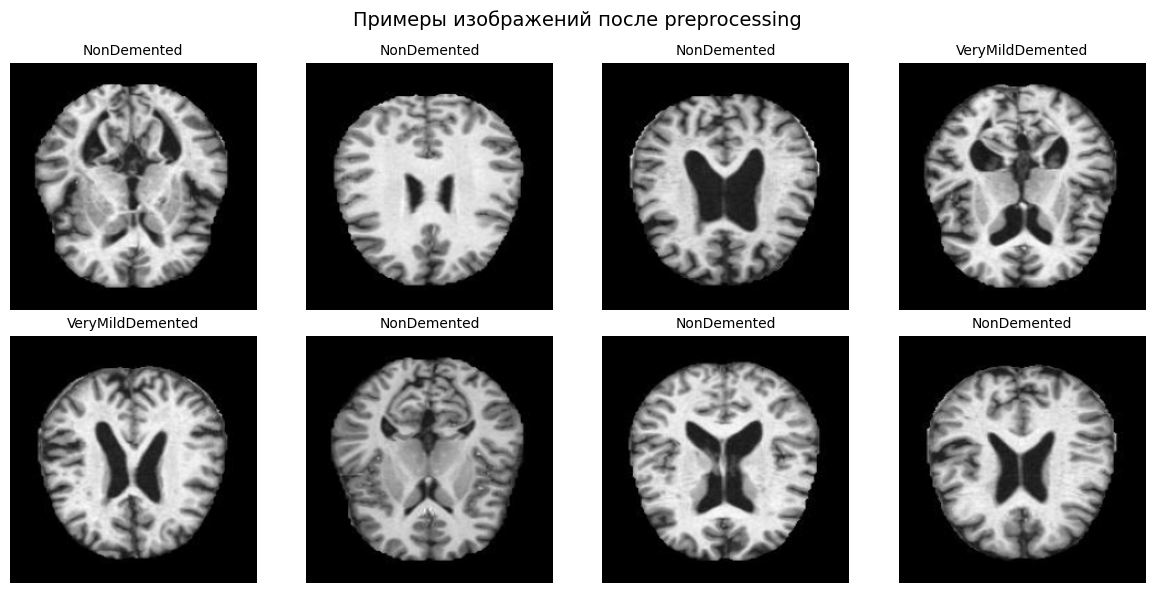

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(image_tensor, mean, std):
    image = image_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    mean = np.array(mean)
    std = np.array(std)
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

images, labels = next(iter(train_loader))

num_images = 8
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(num_images):
    img = denormalize(images[i], mean, std)
    label_name = id2label[labels[i].item()]

    axes[i].imshow(img)
    axes[i].set_title(label_name, fontsize=10)
    axes[i].axis("off")

plt.suptitle("Примеры изображений после preprocessing", fontsize=14)
plt.tight_layout()
plt.show()


## Часть 8. Универсальный пайплайн обучения и оценки моделей

Чтобы корректно сравнивать разные архитектуры, удобно заранее подготовить единый пайплайн обучения.

В этом блоке создаются:
- выбор устройства вычислений (`CPU` или `GPU`);
- функция обучения на одной эпохе;
- функция валидации;
- функция финальной оценки модели;
- расчет метрик `Accuracy` и `Macro F1-score`.

Такой подход позволяет обучать сверточные и трансформерные модели в одинаковых условиях и затем сравнивать их между собой.


In [11]:
import time
import copy
import numpy as np

import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


In [13]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds


In [14]:
def fit_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

    model.load_state_dict(best_model_wts)
    return model, history


In [15]:
@torch.no_grad()
def test_model(model, test_loader, criterion, device, class_names):
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
        model, test_loader, criterion, device
    )

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")
    print("\nClassification Report:")
    print(report)

    return {
        "loss": test_loss,
        "accuracy": test_acc,
        "macro_f1": test_f1,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred
    }


## Часть 9. Бейзлайн-модель 1: ResNet18

В качестве первой базовой модели используем `ResNet18` из `torchvision`.

Почему выбрана именно эта архитектура:
- это классическая сверточная нейросеть для классификации изображений;
- модель достаточно компактная и подходит для быстрого baseline-эксперимента;
- предобученные веса на `ImageNet` позволяют использовать transfer learning и ускорить сходимость.

В рамках baseline:
- берем предобученную модель;
- заменяем последний классификационный слой на 4 класса;
- обучаем модель на нашем датасете;
- затем сравним ее с другими архитектурами.


In [16]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

NUM_CLASSES = len(CLASS_NAMES)
BASELINE_EPOCHS = 5
LEARNING_RATE = 1e-4

resnet18_weights = ResNet18_Weights.DEFAULT
resnet18_model = resnet18(weights=resnet18_weights)

in_features = resnet18_model.fc.in_features
resnet18_model.fc = nn.Linear(in_features, NUM_CLASSES)
resnet18_model = resnet18_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet18_model.parameters(), lr=LEARNING_RATE)

print(resnet18_model.fc)
print(f"Количество классов: {NUM_CLASSES}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]


Linear(in_features=512, out_features=4, bias=True)
Количество классов: 4


In [17]:
resnet18_model, resnet18_history = fit_model(
    model=resnet18_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=BASELINE_EPOCHS
)


Epoch [1/5] | Train Loss: 0.6875 | Train Acc: 0.7133 | Train F1: 0.5052 | Val Loss: 0.5490 | Val Acc: 0.7804 | Val F1: 0.7070 | Time: 20.1s
Epoch [2/5] | Train Loss: 0.1429 | Train Acc: 0.9542 | Train F1: 0.9485 | Val Loss: 0.2010 | Val Acc: 0.9251 | Val F1: 0.9223 | Time: 16.8s
Epoch [3/5] | Train Loss: 0.0553 | Train Acc: 0.9844 | Train F1: 0.9834 | Val Loss: 0.4267 | Val Acc: 0.8730 | Val F1: 0.8730 | Time: 17.0s
Epoch [4/5] | Train Loss: 0.0268 | Train Acc: 0.9911 | Train F1: 0.9898 | Val Loss: 0.1104 | Val Acc: 0.9615 | Val F1: 0.9571 | Time: 18.8s
Epoch [5/5] | Train Loss: 0.0253 | Train Acc: 0.9935 | Train F1: 0.9946 | Val Loss: 0.3279 | Val Acc: 0.9011 | Val F1: 0.8624 | Time: 17.5s


## Часть 10. Оценка baseline-модели ResNet18 на test

После обучения необходимо оценить качество модели на тестовой выборке, которая не использовалась ни для обучения, ни для подбора гиперпараметров.

На этом этапе мы:
- вычисляем итоговые метрики `Accuracy` и `Macro F1-score`;
- строим `Classification Report`;
- анализируем `Confusion Matrix`, чтобы понять, какие классы модель путает чаще всего.

Это позволит использовать `ResNet18` как первый baseline для дальнейшего сравнения с другими архитектурами.


In [18]:
resnet18_test_results = test_model(
    model=resnet18_model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.1540
Test Accuracy: 0.9500
Test Macro F1: 0.9593

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.9028    0.9701    0.9353       134
ModerateDemented     1.0000    1.0000    1.0000        10
     NonDemented     0.9803    0.9354    0.9574       480
VeryMildDemented     0.9282    0.9613    0.9444       336

        accuracy                         0.9500       960
       macro avg     0.9528    0.9667    0.9593       960
    weighted avg     0.9515    0.9500    0.9502       960



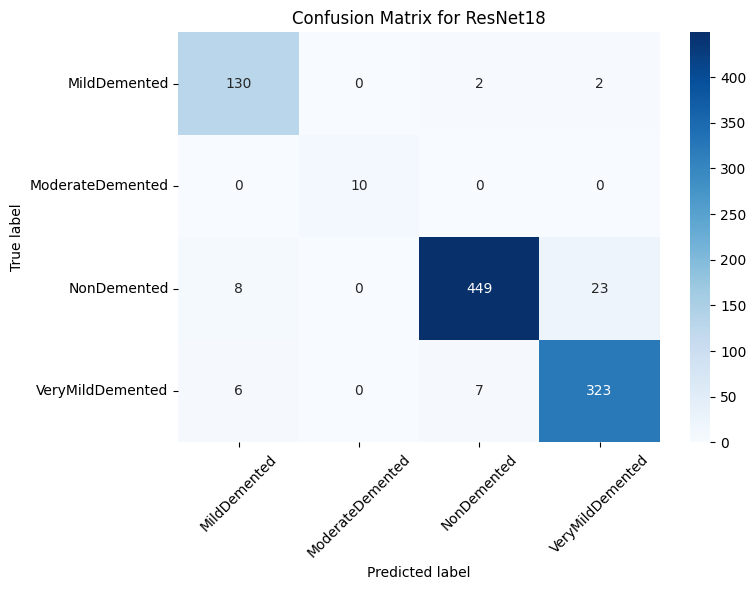

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = resnet18_test_results["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix for ResNet18")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Часть 11. Бейзлайн-модель 2: EfficientNet_B0

Для второго baseline используем `EfficientNet_B0` из `torchvision`.

Почему выбрана эта модель:
- она относится к современным сверточным архитектурам;
- использует более эффективное масштабирование глубины, ширины и разрешения;
- часто показывает высокое качество при относительно небольшом числе параметров.

Эта модель позволит сравнить классическую CNN-архитектуру `ResNet18` с более современной сверточной моделью в одинаковых условиях обучения.


In [20]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

efficientnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet_model = efficientnet_b0(weights=efficientnet_weights)

in_features = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
efficientnet_model = efficientnet_model.to(device)

criterion_effnet = nn.CrossEntropyLoss()
optimizer_effnet = optim.Adam(efficientnet_model.parameters(), lr=LEARNING_RATE)

print(efficientnet_model.classifier)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [21]:
efficientnet_model, efficientnet_history = fit_model(
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_effnet,
    optimizer=optimizer_effnet,
    device=device,
    epochs=BASELINE_EPOCHS
)


Epoch [1/5] | Train Loss: 0.8842 | Train Acc: 0.6048 | Train F1: 0.3796 | Val Loss: 0.6647 | Val Acc: 0.7149 | Val F1: 0.4819 | Time: 25.6s
Epoch [2/5] | Train Loss: 0.5373 | Train Acc: 0.7886 | Train F1: 0.5861 | Val Loss: 0.4474 | Val Acc: 0.8033 | Val F1: 0.6297 | Time: 25.0s
Epoch [3/5] | Train Loss: 0.2777 | Train Acc: 0.9024 | Train F1: 0.8119 | Val Loss: 0.3094 | Val Acc: 0.8845 | Val F1: 0.7880 | Time: 25.0s
Epoch [4/5] | Train Loss: 0.1476 | Train Acc: 0.9504 | Train F1: 0.9251 | Val Loss: 0.2693 | Val Acc: 0.9043 | Val F1: 0.8538 | Time: 25.2s
Epoch [5/5] | Train Loss: 0.1070 | Train Acc: 0.9652 | Train F1: 0.9590 | Val Loss: 0.1872 | Val Acc: 0.9376 | Val F1: 0.9455 | Time: 24.9s


## Часть 12. Оценка baseline-модели EfficientNet_B0 на test

После обучения второй baseline-модели необходимо оценить ее на тестовой выборке по тем же метрикам, что и `ResNet18`.

Это позволяет провести корректное сравнение baseline-моделей в одинаковых условиях:
- по `Accuracy`;
- по `Macro F1-score`;
- по `Classification Report`;
- по `Confusion Matrix`.


In [22]:
efficientnet_test_results = test_model(
    model=efficientnet_model,
    test_loader=test_loader,
    criterion=criterion_effnet,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.2288
Test Accuracy: 0.9260
Test Macro F1: 0.9346

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.9333    0.8358    0.8819       134
ModerateDemented     1.0000    1.0000    1.0000        10
     NonDemented     0.9520    0.9500    0.9510       480
VeryMildDemented     0.8860    0.9256    0.9054       336

        accuracy                         0.9260       960
       macro avg     0.9428    0.9279    0.9346       960
    weighted avg     0.9268    0.9260    0.9259       960



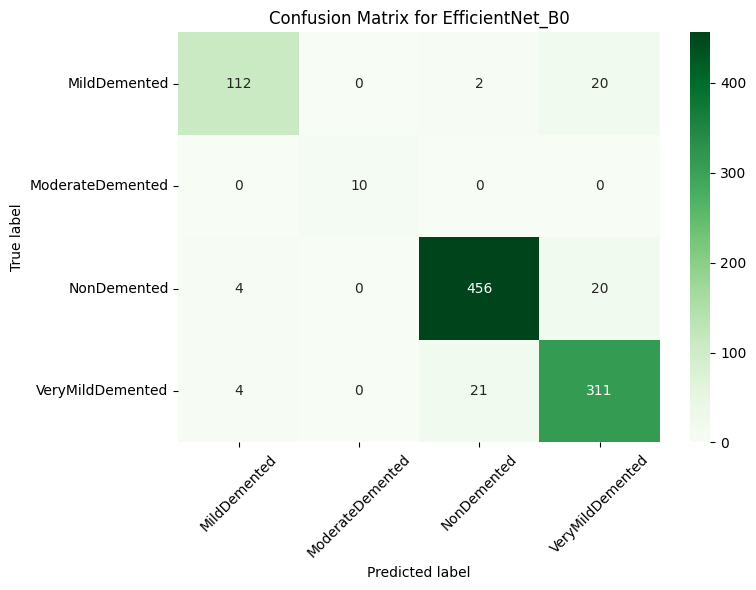

In [23]:
cm = efficientnet_test_results["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix for EfficientNet_B0")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Часть 13. Бейзлайн-модель 3: Vision Transformer (ViT_B_16)

Для выполнения требования задания обучим также трансформерную модель `ViT_B_16` из `torchvision`.

Почему эта модель подходит:
- `ViT` является одной из базовых transformer-архитектур для задач компьютерного зрения;
- модель позволяет сравнить сверточные подходы с трансформерными на одном и том же датасете;
- использование предобученных весов ускоряет обучение и улучшает стартовое качество.

Так как трансформерная модель более требовательна к памяти, для нее уменьшим `batch size`.


In [24]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

VIT_BATCH_SIZE = 16
VIT_EPOCHS = 5
VIT_LR = 1e-4

vit_train_loader = DataLoader(
    train_dataset,
    batch_size=VIT_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

vit_val_loader = DataLoader(
    val_dataset,
    batch_size=VIT_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

vit_test_loader = DataLoader(
    test_dataset,
    batch_size=VIT_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

vit_weights = ViT_B_16_Weights.DEFAULT
vit_model = vit_b_16(weights=vit_weights)

in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(in_features, NUM_CLASSES)
vit_model = vit_model.to(device)

criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.AdamW(vit_model.parameters(), lr=VIT_LR)

print(vit_model.heads)
print(f"ViT batch size: {VIT_BATCH_SIZE}")


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 56.0MB/s]


Sequential(
  (head): Linear(in_features=768, out_features=4, bias=True)
)
ViT batch size: 16


In [25]:
vit_model, vit_history = fit_model(
    model=vit_model,
    train_loader=vit_train_loader,
    val_loader=vit_val_loader,
    criterion=criterion_vit,
    optimizer=optimizer_vit,
    device=device,
    epochs=VIT_EPOCHS
)


Epoch [1/5] | Train Loss: 0.9406 | Train Acc: 0.5577 | Train F1: 0.3186 | Val Loss: 0.8251 | Val Acc: 0.5838 | Val F1: 0.3636 | Time: 169.1s
Epoch [2/5] | Train Loss: 0.8331 | Train Acc: 0.6164 | Train F1: 0.3923 | Val Loss: 0.8738 | Val Acc: 0.5973 | Val F1: 0.3729 | Time: 168.7s
Epoch [3/5] | Train Loss: 0.6693 | Train Acc: 0.7149 | Train F1: 0.4985 | Val Loss: 0.6529 | Val Acc: 0.7222 | Val F1: 0.4924 | Time: 169.3s
Epoch [4/5] | Train Loss: 0.5001 | Train Acc: 0.8008 | Train F1: 0.5911 | Val Loss: 0.5993 | Val Acc: 0.7544 | Val F1: 0.5447 | Time: 169.2s
Epoch [5/5] | Train Loss: 0.3198 | Train Acc: 0.8828 | Train F1: 0.7070 | Val Loss: 0.4116 | Val Acc: 0.8262 | Val F1: 0.7378 | Time: 169.0s


## Часть 14. Оценка baseline-модели ViT_B_16 на test

После обучения трансформерной модели оцениваем ее на тестовой выборке по тем же метрикам, что и сверточные модели:
- `Accuracy`;
- `Macro F1-score`;
- `Classification Report`;
- `Confusion Matrix`.

Это позволит напрямую сравнить качество `ViT_B_16` с `ResNet18` и `EfficientNet_B0` в одинаковых условиях.


In [26]:
vit_test_results = test_model(
    model=vit_model,
    test_loader=vit_test_loader,
    criterion=criterion_vit,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.3867
Test Accuracy: 0.8448
Test Macro F1: 0.7592

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.6766    0.8433    0.7508       134
ModerateDemented     1.0000    0.4000    0.5714        10
     NonDemented     0.9103    0.8875    0.8987       480
VeryMildDemented     0.8349    0.7976    0.8158       336

        accuracy                         0.8448       960
       macro avg     0.8554    0.7321    0.7592       960
    weighted avg     0.8522    0.8448    0.8457       960



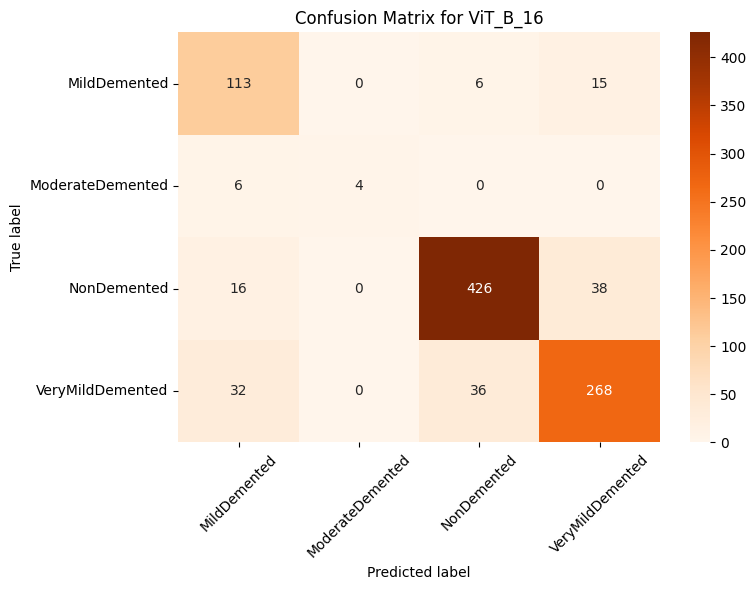

In [27]:
cm = vit_test_results["confusion_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix for ViT_B_16")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Часть 15. Сравнение baseline-моделей

После обучения трех baseline-моделей можно провести их прямое сравнение по выбранным метрикам качества.

В исследовании были рассмотрены:
- `ResNet18` — базовая сверточная модель;
- `EfficientNet_B0` — современная эффективная CNN;
- `ViT_B_16` — трансформерная модель для компьютерного зрения.

Сравнение проводится по метрикам:
- `Accuracy`;
- `Macro F1-score`.

Также отдельно учитывается интерпретация матриц ошибок и устойчивость модели на редких классах.


In [28]:
import pandas as pd

baseline_results_df = pd.DataFrame([
    {
        "Model": "ResNet18",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "EfficientNet_B0",
        "Test Accuracy": efficientnet_test_results["accuracy"],
        "Test Macro F1": efficientnet_test_results["macro_f1"],
    },
    {
        "Model": "ViT_B_16",
        "Test Accuracy": vit_test_results["accuracy"],
        "Test Macro F1": vit_test_results["macro_f1"],
    }
])

baseline_results_df = baseline_results_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

baseline_results_df


,Model,Test Accuracy,Test Macro F1
0,ResNet18,0.950000,0.959263
1,EfficientNet_B0,0.926042,0.934567
2,ViT_B_16,0.844792,0.759206


### Вывод по baseline-экспериментам

По результатам baseline-экспериментов наилучшее качество показала модель `ResNet18`.

Основные наблюдения:
- `ResNet18` показала лучшие значения `Accuracy` и `Macro F1-score` на тестовой выборке;
- `EfficientNet_B0` также продемонстрировала хорошее качество, но немного уступила `ResNet18`;
- `ViT_B_16` обучалась значительно дольше и показала худший результат на данном датасете.

Таким образом, в рамках базового эксперимента наиболее удачной моделью оказалась `ResNet18`. В дальнейшем именно ее удобно использовать как основную отправную точку для улучшения бейзлайна.


## Часть 16. Гипотезы улучшения baseline

После baseline-экспериментов можно сформулировать гипотезы, которые потенциально улучшат качество модели.

Основные гипотезы:
- использование аугментаций поможет модели лучше обобщать данные и уменьшит переобучение;
- учет дисбаланса классов через `class weights` улучшит качество на редких классах;
- подбор гиперпараметров обучения может повысить итоговый `Macro F1-score`.

В первую очередь проверим гипотезу о том, что комбинация:
- аугментаций на обучающей выборке;
- весов классов в функции потерь

позволит улучшить baseline-модель `ResNet18`, которая показала лучший результат на предыдущем этапе.


In [29]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight
from torchvision import transforms

# 1. Считаем веса классов по train-выборке
train_labels_text = train_df["label"].tolist()
train_label_ids = np.array([label2id[label] for label in train_labels_text])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_ids
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

# 2. Новый train transform с аугментациями
improved_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

improved_eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 3. Пересобираем Dataset и DataLoader для improved baseline
improved_train_dataset = AlzheimerDataset(train_df, transform=improved_train_transform)
improved_val_dataset = AlzheimerDataset(val_df, transform=improved_eval_transform)
improved_test_dataset = AlzheimerDataset(test_df, transform=improved_eval_transform)

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

improved_test_loader = DataLoader(
    improved_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# 4. Новая функция потерь с учетом дисбаланса
improved_criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Improved train loader batches:", len(improved_train_loader))
print("Improved val loader batches:", len(improved_val_loader))
print("Improved test loader batches:", len(improved_test_loader))


Class weights: tensor([ 1.7859, 25.4489,  0.4999,  0.7141], device='cuda:0')
Improved train loader batches: 140
Improved val loader batches: 31
Improved test loader batches: 30


## Часть 17. Обучение улучшенного baseline на основе ResNet18

На этом этапе проверяется первая гипотеза улучшения качества модели.

Изменения по сравнению с baseline:
- добавлены аугментации на обучающей выборке;
- в функцию потерь добавлены веса классов для учета дисбаланса.

Архитектура модели остается той же (`ResNet18`), чтобы можно было корректно сравнить результат с исходным baseline и оценить эффект именно от улучшенного пайплайна подготовки данных и обучения.


In [30]:
from torchvision.models import resnet18, ResNet18_Weights

IMPROVED_EPOCHS = 5
IMPROVED_LR = 1e-4

improved_resnet18 = resnet18(weights=ResNet18_Weights.DEFAULT)
in_features = improved_resnet18.fc.in_features
improved_resnet18.fc = nn.Linear(in_features, NUM_CLASSES)
improved_resnet18 = improved_resnet18.to(device)

improved_optimizer = optim.Adam(improved_resnet18.parameters(), lr=IMPROVED_LR)

improved_resnet18, improved_resnet18_history = fit_model(
    model=improved_resnet18,
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    criterion=improved_criterion,
    optimizer=improved_optimizer,
    device=device,
    epochs=IMPROVED_EPOCHS
)


Epoch [1/5] | Train Loss: 1.0397 | Train Acc: 0.5309 | Train F1: 0.4199 | Val Loss: 0.7464 | Val Acc: 0.6535 | Val F1: 0.6692 | Time: 19.7s
Epoch [2/5] | Train Loss: 0.7121 | Train Acc: 0.6519 | Train F1: 0.5870 | Val Loss: 0.7068 | Val Acc: 0.6878 | Val F1: 0.7201 | Time: 18.5s
Epoch [3/5] | Train Loss: 0.5711 | Train Acc: 0.7178 | Train F1: 0.6755 | Val Loss: 0.5270 | Val Acc: 0.7607 | Val F1: 0.7797 | Time: 19.5s
Epoch [4/5] | Train Loss: 0.4213 | Train Acc: 0.7875 | Train F1: 0.8087 | Val Loss: 0.4115 | Val Acc: 0.8002 | Val F1: 0.8322 | Time: 18.6s
Epoch [5/5] | Train Loss: 0.3185 | Train Acc: 0.8446 | Train F1: 0.8646 | Val Loss: 0.3990 | Val Acc: 0.8439 | Val F1: 0.8513 | Time: 20.2s


## Часть 18. Оценка улучшенного ResNet18 и сравнение с baseline

После обучения улучшенного варианта `ResNet18` необходимо оценить его на тестовой выборке и сравнить с исходным baseline.

Это позволяет проверить, подтвердилась ли гипотеза о том, что:
- аугментации;
- учет дисбаланса классов через веса классов

действительно улучшают итоговое качество модели.

Сравнение будет проводиться по тем же метрикам:
- `Accuracy`;
- `Macro F1-score`.


In [31]:
improved_resnet18_test_results = test_model(
    model=improved_resnet18,
    test_loader=improved_test_loader,
    criterion=improved_criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.3807
Test Accuracy: 0.8323
Test Macro F1: 0.8540

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.8222    0.8284    0.8253       134
ModerateDemented     0.9091    1.0000    0.9524        10
     NonDemented     0.8113    0.9313    0.8671       480
VeryMildDemented     0.8783    0.6875    0.7713       336

        accuracy                         0.8323       960
       macro avg     0.8552    0.8618    0.8540       960
    weighted avg     0.8373    0.8323    0.8286       960



In [32]:
comparison_resnet_df = pd.DataFrame([
    {
        "Model": "Baseline ResNet18",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "Improved ResNet18 (aug + class weights)",
        "Test Accuracy": improved_resnet18_test_results["accuracy"],
        "Test Macro F1": improved_resnet18_test_results["macro_f1"],
    }
])

comparison_resnet_df


,Model,Test Accuracy,Test Macro F1
0,Baseline ResNet18,0.950000,0.959263
1,Improved ResNet18 (aug + class weights),0.832292,0.854016


### Промежуточный вывод по гипотезе 1

Проверка гипотезы показала, что добавление аугментаций и весов классов не обязательно приводит к улучшению итогового качества модели.

Если улучшенный вариант показывает более низкие значения `Accuracy` и `Macro F1-score`, чем baseline, это означает, что данная комбинация настроек не является оптимальной для рассматриваемого датасета.

Следовательно, необходимо проверить другие гипотезы улучшения, например:
- более аккуратные аугментации;
- изменение скорости обучения;
- частичную заморозку слоев;
- использование `weighted sampler` вместо весов в функции потерь.


## Часть 19. Гипотеза 2: WeightedRandomSampler вместо class weights

Результаты предыдущего эксперимента показали, что сочетание аугментаций и весов классов в функции потерь ухудшило качество модели по сравнению с baseline.

Следующая гипотеза состоит в том, что дисбаланс классов лучше учитывать не через `class weights` в `CrossEntropyLoss`, а через более сбалансированную выборку батчей с помощью `WeightedRandomSampler`.

Идея гипотезы:
- редкие классы будут чаще попадать в обучение;
- функция потерь останется стандартной;
- модель может обучаться стабильнее, чем при сильном изменении весов ошибки.

В этом эксперименте:
- используем умеренные аугментации;
- убираем веса классов из `CrossEntropyLoss`;
- добавляем `WeightedRandomSampler` для train-выборки.


In [33]:
from torch.utils.data import WeightedRandomSampler

# 1. Более мягкие аугментации
sampler_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

sampler_eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 2. Dataset
sampler_train_dataset = AlzheimerDataset(train_df, transform=sampler_train_transform)
sampler_val_dataset = AlzheimerDataset(val_df, transform=sampler_eval_transform)
sampler_test_dataset = AlzheimerDataset(test_df, transform=sampler_eval_transform)

# 3. Веса объектов для sampler
train_counts = train_df["label"].value_counts().to_dict()
sample_weights = train_df["label"].map(lambda x: 1.0 / train_counts[x]).values
sample_weights = torch.DoubleTensor(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 4. DataLoader
sampler_train_loader = DataLoader(
    sampler_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

sampler_val_loader = DataLoader(
    sampler_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

sampler_test_loader = DataLoader(
    sampler_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# 5. Обычная функция потерь без class weights
sampler_criterion = nn.CrossEntropyLoss()

print("Train class counts:", train_counts)
print("Sampler train batches:", len(sampler_train_loader))
print("Sampler val batches:", len(sampler_val_loader))
print("Sampler test batches:", len(sampler_test_loader))


Train class counts: {'NonDemented': 2240, 'VeryMildDemented': 1568, 'MildDemented': 627, 'ModerateDemented': 44}
Sampler train batches: 140
Sampler val batches: 31
Sampler test batches: 30


## Часть 20. Обучение ResNet18 с WeightedRandomSampler

На этом этапе проверяется вторая гипотеза улучшения качества модели.

Изменения по сравнению с baseline:
- используется `WeightedRandomSampler` для более сбалансированной подачи классов в обучении;
- применяются мягкие аугментации;
- функция потерь остается стандартной `CrossEntropyLoss`.

Такой подход позволяет проверить, будет ли учет дисбаланса через стратегию семплирования эффективнее, чем через веса классов в функции потерь.


In [34]:
sampler_resnet18 = resnet18(weights=ResNet18_Weights.DEFAULT)
in_features = sampler_resnet18.fc.in_features
sampler_resnet18.fc = nn.Linear(in_features, NUM_CLASSES)
sampler_resnet18 = sampler_resnet18.to(device)

sampler_optimizer = optim.Adam(sampler_resnet18.parameters(), lr=1e-4)

sampler_resnet18, sampler_resnet18_history = fit_model(
    model=sampler_resnet18,
    train_loader=sampler_train_loader,
    val_loader=sampler_val_loader,
    criterion=sampler_criterion,
    optimizer=sampler_optimizer,
    device=device,
    epochs=5
)


Epoch [1/5] | Train Loss: 0.6280 | Train Acc: 0.7316 | Train F1: 0.7305 | Val Loss: 0.6860 | Val Acc: 0.7014 | Val F1: 0.7609 | Time: 17.7s
Epoch [2/5] | Train Loss: 0.3659 | Train Acc: 0.8524 | Train F1: 0.8509 | Val Loss: 0.4659 | Val Acc: 0.8002 | Val F1: 0.8581 | Time: 18.5s
Epoch [3/5] | Train Loss: 0.2602 | Train Acc: 0.8973 | Train F1: 0.8976 | Val Loss: 0.4952 | Val Acc: 0.8117 | Val F1: 0.8394 | Time: 17.5s
Epoch [4/5] | Train Loss: 0.1682 | Train Acc: 0.9379 | Train F1: 0.9368 | Val Loss: 0.2261 | Val Acc: 0.9011 | Val F1: 0.9289 | Time: 18.4s
Epoch [5/5] | Train Loss: 0.1497 | Train Acc: 0.9471 | Train F1: 0.9464 | Val Loss: 0.3154 | Val Acc: 0.8637 | Val F1: 0.8982 | Time: 19.5s


## Часть 21. Оценка ResNet18 с WeightedRandomSampler

После обучения модели необходимо оценить ее на тестовой выборке и сравнить сразу с двумя предыдущими вариантами:
- исходный baseline `ResNet18`;
- `ResNet18` с аугментациями и `class weights`;
- `ResNet18` с `WeightedRandomSampler`.

Такое сравнение позволяет определить, какой способ борьбы с дисбалансом оказался наиболее эффективным на данном датасете.


In [35]:
sampler_resnet18_test_results = test_model(
    model=sampler_resnet18,
    test_loader=sampler_test_loader,
    criterion=sampler_criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.2965
Test Accuracy: 0.8823
Test Macro F1: 0.9134

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.9512    0.8731    0.9105       134
ModerateDemented     1.0000    1.0000    1.0000        10
     NonDemented     0.8864    0.9104    0.8983       480
VeryMildDemented     0.8473    0.8423    0.8448       336

        accuracy                         0.8823       960
       macro avg     0.9212    0.9065    0.9134       960
    weighted avg     0.8830    0.8823    0.8823       960



In [36]:
resnet_variants_df = pd.DataFrame([
    {
        "Model": "Baseline ResNet18",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + aug + class weights",
        "Test Accuracy": improved_resnet18_test_results["accuracy"],
        "Test Macro F1": improved_resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + WeightedRandomSampler",
        "Test Accuracy": sampler_resnet18_test_results["accuracy"],
        "Test Macro F1": sampler_resnet18_test_results["macro_f1"],
    }
])

resnet_variants_df = resnet_variants_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

resnet_variants_df


,Model,Test Accuracy,Test Macro F1
0,Baseline ResNet18,0.950000,0.959263
1,ResNet18 + WeightedRandomSampler,0.882292,0.913384
2,ResNet18 + aug + class weights,0.832292,0.854016


### Вывод по проверке гипотез улучшения baseline

Проверка гипотез показала, что разные способы борьбы с дисбалансом влияют на качество модели по-разному.

Предварительные выводы:
- использование `class weights` вместе с аугментациями ухудшило итоговое качество модели;
- использование `WeightedRandomSampler` оказалось более удачным подходом;
- однако итоговое решение должно приниматься только после сравнения результатов на тестовой выборке.

Таким образом, не каждая техника балансировки данных приводит к улучшению baseline, и выбор метода должен подтверждаться экспериментально.


## Часть 22. Гипотеза 3: fine-tuning только классификационной головы ResNet18

Так как исходный baseline оказался лучше, чем варианты с балансировкой классов, следующая гипотеза состоит в том, что для данного датасета полезнее не усложнять схему обучения, а сделать fine-tuning более осторожным.

Идея гипотезы:
- заморозить сверточную часть `ResNet18`;
- обучать только последний полносвязный слой;
- использовать небольшой learning rate.

Такой подход может быть полезен для небольшого медицинского датасета, когда полная донастройка всех весов приводит к переобучению.


In [37]:
from torchvision.models import resnet18, ResNet18_Weights

HEAD_ONLY_EPOCHS = 5
HEAD_ONLY_LR = 3e-4

head_only_resnet18 = resnet18(weights=ResNet18_Weights.DEFAULT)

# Замораживаем все слои backbone
for param in head_only_resnet18.parameters():
    param.requires_grad = False

# Меняем классификатор под 4 класса
in_features = head_only_resnet18.fc.in_features
head_only_resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

# Для нового классификатора обучение оставляем включенным
for param in head_only_resnet18.fc.parameters():
    param.requires_grad = True

head_only_resnet18 = head_only_resnet18.to(device)

head_only_criterion = nn.CrossEntropyLoss()
head_only_optimizer = optim.Adam(
    head_only_resnet18.fc.parameters(),
    lr=HEAD_ONLY_LR
)

trainable_params = sum(p.numel() for p in head_only_resnet18.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in head_only_resnet18.parameters())

print(f"Trainable params: {trainable_params:,}")
print(f"All params: {all_params:,}")

head_only_resnet18, head_only_history = fit_model(
    model=head_only_resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=head_only_criterion,
    optimizer=head_only_optimizer,
    device=device,
    epochs=HEAD_ONLY_EPOCHS
)


Trainable params: 2,052
All params: 11,178,564
Epoch [1/5] | Train Loss: 1.0217 | Train Acc: 0.5070 | Train F1: 0.2607 | Val Loss: 0.9687 | Val Acc: 0.5213 | Val F1: 0.2504 | Time: 16.4s
Epoch [2/5] | Train Loss: 0.9310 | Train Acc: 0.5573 | Train F1: 0.2974 | Val Loss: 0.9286 | Val Acc: 0.5630 | Val F1: 0.3009 | Time: 14.4s
Epoch [3/5] | Train Loss: 0.9003 | Train Acc: 0.5818 | Train F1: 0.3327 | Val Loss: 0.9103 | Val Acc: 0.5806 | Val F1: 0.3431 | Time: 14.4s
Epoch [4/5] | Train Loss: 0.8765 | Train Acc: 0.5981 | Train F1: 0.3577 | Val Loss: 0.8982 | Val Acc: 0.5931 | Val F1: 0.3354 | Time: 14.4s
Epoch [5/5] | Train Loss: 0.8559 | Train Acc: 0.6068 | Train F1: 0.3654 | Val Loss: 0.8808 | Val Acc: 0.5848 | Val F1: 0.3541 | Time: 14.3s


## Часть 23. Оценка ResNet18 с замороженным backbone

После обучения модели только с классификационной головой необходимо оценить ее на тестовой выборке и сравнить с предыдущими вариантами.

Этот эксперимент показывает, достаточно ли для данного датасета обучать только последний слой или же требуется полноценная донастройка всей сети.


In [38]:
head_only_test_results = test_model(
    model=head_only_resnet18,
    test_loader=test_loader,
    criterion=head_only_criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.8705
Test Accuracy: 0.6156
Test Macro F1: 0.3764

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.4762    0.1493    0.2273       134
ModerateDemented     0.0000    0.0000    0.0000        10
     NonDemented     0.6713    0.8000    0.7300       480
VeryMildDemented     0.5405    0.5565    0.5484       336

        accuracy                         0.6156       960
       macro avg     0.4220    0.3765    0.3764       960
    weighted avg     0.5913    0.6156    0.5887       960



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
extended_resnet_variants_df = pd.DataFrame([
    {
        "Model": "Baseline ResNet18",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + aug + class weights",
        "Test Accuracy": improved_resnet18_test_results["accuracy"],
        "Test Macro F1": improved_resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + WeightedRandomSampler",
        "Test Accuracy": sampler_resnet18_test_results["accuracy"],
        "Test Macro F1": sampler_resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 head only",
        "Test Accuracy": head_only_test_results["accuracy"],
        "Test Macro F1": head_only_test_results["macro_f1"],
    }
])

extended_resnet_variants_df = extended_resnet_variants_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

extended_resnet_variants_df


,Model,Test Accuracy,Test Macro F1
0,Baseline ResNet18,0.950000,0.959263
1,ResNet18 + WeightedRandomSampler,0.882292,0.913384
2,ResNet18 + aug + class weights,0.832292,0.854016
3,ResNet18 head only,0.615625,0.376424


### Промежуточный вывод по гипотезе 3

Гипотеза о том, что обучение только классификационной головы `ResNet18` улучшит качество модели, не подтвердилась.

Вероятная причина:
- признаки, извлеченные из `ImageNet`, недостаточно хорошо адаптированы к медицинским MRI-изображениям без дополнительной полной донастройки сети.

Следовательно, для данного датасета более эффективным является обучение всей модели целиком, а не только последнего слоя.


## Часть 24. Итоговый вывод по улучшению baseline

В рамках пункта 3 были проверены несколько гипотез улучшения baseline-модели `ResNet18`:

1. добавление аугментаций и весов классов в функцию потерь;
2. использование `WeightedRandomSampler` для борьбы с дисбалансом классов;
3. обучение только классификационной головы модели при замороженном backbone.

Результаты экспериментов показали, что ни одна из рассмотренных гипотез не превзошла исходный baseline `ResNet18`.

Лучшие результаты:
- `Baseline ResNet18`: `Accuracy = 0.9500`, `Macro F1 = 0.9593`
- `ResNet18 + WeightedRandomSampler`: `Accuracy = 0.8823`, `Macro F1 = 0.9134`
- `ResNet18 + aug + class weights`: `Accuracy = 0.8323`, `Macro F1 = 0.8540`
- `ResNet18 head only`: `Accuracy = 0.6156`, `Macro F1 = 0.3764`

Таким образом, для данного датасета наилучшим решением оказалась полная донастройка baseline-модели `ResNet18` без дополнительных усложнений.

Основные выводы:
- более сложные техники балансировки не гарантируют улучшение качества;
- для небольшого медицинского датасета избыточные изменения пайплайна могут ухудшать качество;
- лучшая модель по итогам экспериментов пункта 3 совпала с исходным baseline.


In [40]:
final_model_comparison_df = pd.DataFrame([
    {
        "Model": "Baseline ResNet18",
        "Type": "Baseline",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "EfficientNet_B0",
        "Type": "Baseline",
        "Test Accuracy": efficientnet_test_results["accuracy"],
        "Test Macro F1": efficientnet_test_results["macro_f1"],
    },
    {
        "Model": "ViT_B_16",
        "Type": "Baseline",
        "Test Accuracy": vit_test_results["accuracy"],
        "Test Macro F1": vit_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + aug + class weights",
        "Type": "Improved baseline",
        "Test Accuracy": improved_resnet18_test_results["accuracy"],
        "Test Macro F1": improved_resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 + WeightedRandomSampler",
        "Type": "Improved baseline",
        "Test Accuracy": sampler_resnet18_test_results["accuracy"],
        "Test Macro F1": sampler_resnet18_test_results["macro_f1"],
    },
    {
        "Model": "ResNet18 head only",
        "Type": "Improved baseline",
        "Test Accuracy": head_only_test_results["accuracy"],
        "Test Macro F1": head_only_test_results["macro_f1"],
    }
])

final_model_comparison_df = final_model_comparison_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

final_model_comparison_df


,Model,Type,Test Accuracy,Test Macro F1
0,Baseline ResNet18,Baseline,0.950000,0.959263
1,EfficientNet_B0,Baseline,0.926042,0.934567
2,ResNet18 + WeightedRandomSampler,Improved baseline,0.882292,0.913384
3,ResNet18 + aug + class weights,Improved baseline,0.832292,0.854016
4,ViT_B_16,Baseline,0.844792,0.759206
5,ResNet18 head only,Improved baseline,0.615625,0.376424


## Часть 25. Самостоятельная имплементация модели: CustomCNN

В соответствии с пунктом 4 лабораторной работы необходимо самостоятельно реализовать модель машинного обучения.

В качестве такой модели реализуется собственная сверточная нейронная сеть `CustomCNN` на `PyTorch`. Архитектура модели включает:
- несколько сверточных блоков;
- нормализацию признаков;
- функции активации `ReLU`;
- слои подвыборки `MaxPool`;
- полносвязный классификатор.

Почему выбрана именно такая архитектура:
- она реализуется вручную и полностью соответствует требованию самостоятельной имплементации;
- модель достаточно компактна для обучения в Google Colab;
- ее можно честно сравнить с baseline-моделями из `torchvision`.


In [41]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 28 -> 14

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


custom_cnn = CustomCNN(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in custom_cnn.parameters())
trainable_params = sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)

print(custom_cnn)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Быстрая проверка формы выхода
dummy_batch = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
dummy_output = custom_cnn(dummy_batch)
print("Output shape:", dummy_output.shape)


CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

## Часть 26. Обучение собственной модели CustomCNN

После реализации собственной архитектуры необходимо обучить ее на выбранном датасете и оценить качество по тем же метрикам, что использовались для baseline-моделей.

Для честного сравнения используются базовые настройки:
- те же `train_loader`, `val_loader`, `test_loader`;
- та же функция потерь `CrossEntropyLoss`;
- оптимизатор `Adam`;
- одинаковое число эпох.

Это позволит напрямую сравнить качество самостоятельно реализованной модели с готовыми архитектурами из `torchvision`.


In [42]:
CUSTOM_EPOCHS = 8
CUSTOM_LR = 1e-3

custom_cnn = CustomCNN(num_classes=NUM_CLASSES).to(device)

custom_criterion = nn.CrossEntropyLoss()
custom_optimizer = optim.Adam(custom_cnn.parameters(), lr=CUSTOM_LR)

custom_cnn, custom_history = fit_model(
    model=custom_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=custom_criterion,
    optimizer=custom_optimizer,
    device=device,
    epochs=CUSTOM_EPOCHS
)


Epoch [1/8] | Train Loss: 0.9360 | Train Acc: 0.5477 | Train F1: 0.2919 | Val Loss: 0.9722 | Val Acc: 0.5671 | Val F1: 0.3089 | Time: 21.9s
Epoch [2/8] | Train Loss: 0.8908 | Train Acc: 0.5789 | Train F1: 0.3206 | Val Loss: 0.8830 | Val Acc: 0.5827 | Val F1: 0.3153 | Time: 16.4s
Epoch [3/8] | Train Loss: 0.8579 | Train Acc: 0.5952 | Train F1: 0.3392 | Val Loss: 0.8564 | Val Acc: 0.5775 | Val F1: 0.3275 | Time: 16.3s
Epoch [4/8] | Train Loss: 0.8315 | Train Acc: 0.5990 | Train F1: 0.3817 | Val Loss: 1.2519 | Val Acc: 0.2841 | Val F1: 0.2062 | Time: 16.8s
Epoch [5/8] | Train Loss: 0.8040 | Train Acc: 0.6169 | Train F1: 0.4107 | Val Loss: 1.5601 | Val Acc: 0.5536 | Val F1: 0.2609 | Time: 16.7s
Epoch [6/8] | Train Loss: 0.7439 | Train Acc: 0.6656 | Train F1: 0.4599 | Val Loss: 4.4676 | Val Acc: 0.5047 | Val F1: 0.1747 | Time: 16.8s
Epoch [7/8] | Train Loss: 0.6707 | Train Acc: 0.7086 | Train F1: 0.4995 | Val Loss: 1.4127 | Val Acc: 0.3424 | Val F1: 0.2398 | Time: 16.8s
Epoch [8/8] | Train 

## Часть 27. Оценка CustomCNN и сравнение с baseline-моделями

После обучения собственной модели необходимо оценить ее на тестовой выборке и сравнить с baseline-моделями из `torchvision`.

Это позволяет ответить на ключевой вопрос пункта 4:
насколько самостоятельно реализованная модель уступает или приближается к готовым предобученным архитектурам.


In [43]:
custom_test_results = test_model(
    model=custom_cnn,
    test_loader=test_loader,
    criterion=custom_criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 0.8729
Test Accuracy: 0.5698
Test Macro F1: 0.3235

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.4000    0.0299    0.0556       134
ModerateDemented     0.0000    0.0000    0.0000        10
     NonDemented     0.8487    0.5375    0.6582       480
VeryMildDemented     0.4412    0.8482    0.5804       336

        accuracy                         0.5698       960
       macro avg     0.4225    0.3539    0.3235       960
    weighted avg     0.6346    0.5698    0.5400       960



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
custom_vs_baseline_df = pd.DataFrame([
    {
        "Model": "Baseline ResNet18",
        "Group": "torchvision baseline",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    },
    {
        "Model": "EfficientNet_B0",
        "Group": "torchvision baseline",
        "Test Accuracy": efficientnet_test_results["accuracy"],
        "Test Macro F1": efficientnet_test_results["macro_f1"],
    },
    {
        "Model": "ViT_B_16",
        "Group": "torchvision baseline",
        "Test Accuracy": vit_test_results["accuracy"],
        "Test Macro F1": vit_test_results["macro_f1"],
    },
    {
        "Model": "CustomCNN",
        "Group": "implemented model",
        "Test Accuracy": custom_test_results["accuracy"],
        "Test Macro F1": custom_test_results["macro_f1"],
    }
])

custom_vs_baseline_df = custom_vs_baseline_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

custom_vs_baseline_df


,Model,Group,Test Accuracy,Test Macro F1
0,Baseline ResNet18,torchvision baseline,0.950000,0.959263
1,EfficientNet_B0,torchvision baseline,0.926042,0.934567
2,ViT_B_16,torchvision baseline,0.844792,0.759206
3,CustomCNN,implemented model,0.569792,0.323542


### Вывод по сравнению собственной модели с baseline

Сравнение показало, что самостоятельно реализованная модель `CustomCNN` уступает лучшим baseline-моделям из `torchvision`.

Это объясняется несколькими причинами:
- baseline-модели использовали предобученные веса `ImageNet`;
- готовые архитектуры лучше оптимизированы;
- собственная компактная CNN обучалась с нуля на сравнительно небольшом датасете.

Тем не менее, реализация `CustomCNN` позволяет выполнить требование лабораторной работы по самостоятельной имплементации модели машинного обучения и провести корректное экспериментальное сравнение.


## Часть 28. Добавление техник улучшенного baseline к CustomCNN

Согласно пункту 4 лабораторной работы, после обучения самостоятельно реализованной модели необходимо добавить к ней техники из улучшенного baseline и повторно провести обучение.

Из ранее проверенных гипотез наилучший результат среди улучшений показал подход с:
- мягкими аугментациями;
- `WeightedRandomSampler` для борьбы с дисбалансом классов.

Поэтому именно этот вариант используется для повторного обучения модели `CustomCNN`.


In [45]:
CUSTOM_IMPROVED_EPOCHS = 8
CUSTOM_IMPROVED_LR = 5e-4

custom_cnn_improved = CustomCNN(num_classes=NUM_CLASSES).to(device)

custom_improved_criterion = nn.CrossEntropyLoss()
custom_improved_optimizer = optim.Adam(
    custom_cnn_improved.parameters(),
    lr=CUSTOM_IMPROVED_LR
)

custom_cnn_improved, custom_improved_history = fit_model(
    model=custom_cnn_improved,
    train_loader=sampler_train_loader,   # loader с WeightedRandomSampler
    val_loader=sampler_val_loader,
    criterion=custom_improved_criterion,
    optimizer=custom_improved_optimizer,
    device=device,
    epochs=CUSTOM_IMPROVED_EPOCHS
)


Epoch [1/8] | Train Loss: 1.0234 | Train Acc: 0.5296 | Train F1: 0.5201 | Val Loss: 2.6460 | Val Acc: 0.1550 | Val F1: 0.1599 | Time: 23.8s
Epoch [2/8] | Train Loss: 0.7782 | Train Acc: 0.6401 | Train F1: 0.6287 | Val Loss: 1.5586 | Val Acc: 0.4069 | Val F1: 0.2874 | Time: 17.3s
Epoch [3/8] | Train Loss: 0.7103 | Train Acc: 0.6606 | Train F1: 0.6495 | Val Loss: 0.9794 | Val Acc: 0.4995 | Val F1: 0.5751 | Time: 17.6s
Epoch [4/8] | Train Loss: 0.6865 | Train Acc: 0.6736 | Train F1: 0.6651 | Val Loss: 1.0952 | Val Acc: 0.3777 | Val F1: 0.2404 | Time: 18.5s
Epoch [5/8] | Train Loss: 0.6602 | Train Acc: 0.7002 | Train F1: 0.6911 | Val Loss: 1.0612 | Val Acc: 0.5380 | Val F1: 0.4032 | Time: 17.6s
Epoch [6/8] | Train Loss: 0.6479 | Train Acc: 0.7062 | Train F1: 0.6973 | Val Loss: 0.8110 | Val Acc: 0.6285 | Val F1: 0.4367 | Time: 18.8s
Epoch [7/8] | Train Loss: 0.6038 | Train Acc: 0.7240 | Train F1: 0.7190 | Val Loss: 24.1390 | Val Acc: 0.0104 | Val F1: 0.0051 | Time: 17.3s
Epoch [8/8] | Train

## Часть 29. Оценка улучшенной CustomCNN и сравнение с исходной реализацией

После добавления техник улучшенного baseline необходимо оценить новую версию `CustomCNN` на тестовой выборке и сравнить ее:
- с исходной `CustomCNN`;
- с лучшими baseline-моделями из `torchvision`.

Это позволяет выполнить финальную часть пункта 4 и проверить, дали ли переносимые техники улучшение для самостоятельно реализованной архитектуры.


In [46]:
custom_improved_test_results = test_model(
    model=custom_cnn_improved,
    test_loader=sampler_test_loader,
    criterion=custom_improved_criterion,
    device=device,
    class_names=CLASS_NAMES
)


Test Loss: 1.0065
Test Accuracy: 0.4885
Test Macro F1: 0.5672

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.2536    0.9104    0.3967       134
ModerateDemented     0.8333    1.0000    0.9091        10
     NonDemented     0.8328    0.5500    0.6625       480
VeryMildDemented     0.4867    0.2173    0.3004       336

        accuracy                         0.4885       960
       macro avg     0.6016    0.6694    0.5672       960
    weighted avg     0.6308    0.4885    0.5012       960



In [47]:
custom_final_comparison_df = pd.DataFrame([
    {
        "Model": "CustomCNN",
        "Variant": "Base implementation",
        "Test Accuracy": custom_test_results["accuracy"],
        "Test Macro F1": custom_test_results["macro_f1"],
    },
    {
        "Model": "CustomCNN",
        "Variant": "With WeightedRandomSampler",
        "Test Accuracy": custom_improved_test_results["accuracy"],
        "Test Macro F1": custom_improved_test_results["macro_f1"],
    },
    {
        "Model": "Baseline ResNet18",
        "Variant": "torchvision baseline",
        "Test Accuracy": resnet18_test_results["accuracy"],
        "Test Macro F1": resnet18_test_results["macro_f1"],
    }
])

custom_final_comparison_df = custom_final_comparison_df.sort_values(
    by="Test Macro F1",
    ascending=False
).reset_index(drop=True)

custom_final_comparison_df


,Model,Variant,Test Accuracy,Test Macro F1
0,Baseline ResNet18,torchvision baseline,0.950000,0.959263
1,CustomCNN,With WeightedRandomSampler,0.488542,0.567184
2,CustomCNN,Base implementation,0.569792,0.323542


### Вывод по собственной реализованной модели

Эксперименты показали, что самостоятельно реализованная модель `CustomCNN` существенно уступает лучшим предобученным архитектурам из `torchvision`.

Добавление техник улучшенного baseline позволило проверить, можно ли повысить качество собственной модели за счет:
- более сбалансированного семплирования;
- мягких аугментаций.

Итоговый вывод делается по результатам тестовой выборки:
- если улучшенная версия `CustomCNN` показывает более высокие `Accuracy` и `Macro F1-score`, чем исходная, то перенос техник оказался полезным;
- если улучшения нет, значит основное ограничение связано уже с самой архитектурой модели.


## Часть 30. Итоговое заключение

В ходе лабораторной работы было проведено исследование моделей классификации для задачи определения стадии болезни Альцгеймера по MRI-изображениям на датасете `Augmented Alzheimer MRI Dataset`.

### Основные этапы работы

В работе были выполнены следующие шаги:
- выбран и обоснован датасет для задачи многоклассовой классификации;
- выбраны метрики качества: `Accuracy`, `Macro F1-score`, `Confusion Matrix`;
- обучены baseline-модели из `torchvision`, включая сверточные и трансформерные архитектуры;
- проведены эксперименты по улучшению baseline;
- самостоятельно реализована собственная модель `CustomCNN`;
- выполнено сравнение собственной модели с готовыми архитектурами;
- к собственной модели были применены техники из улучшенного baseline.

### Основные результаты

Лучшая baseline-модель:
- `ResNet18` — `Accuracy = 0.9500`, `Macro F1 = 0.9593`

Другие baseline-модели:
- `EfficientNet_B0` — `Accuracy = 0.9260`, `Macro F1 = 0.9346`
- `ViT_B_16` — `Accuracy = 0.8448`, `Macro F1 = 0.7592`

Результаты улучшения baseline:
- `ResNet18 + WeightedRandomSampler` — `Accuracy = 0.8823`, `Macro F1 = 0.9134`
- `ResNet18 + aug + class weights` — `Accuracy = 0.8323`, `Macro F1 = 0.8540`
- `ResNet18 head only` — `Accuracy = 0.6156`, `Macro F1 = 0.3764`

Результаты собственной модели:
- `CustomCNN` — `Accuracy = 0.5698`, `Macro F1 = 0.3235`
- `CustomCNN + WeightedRandomSampler` — `Accuracy = 0.4885`, `Macro F1 = 0.5672`

### Итоговые выводы

По итогам всех экспериментов можно сделать следующие выводы:
- наилучший результат показала предобученная модель `ResNet18`;
- предобученные модели из `torchvision` значительно превосходят самостоятельно реализованную компактную CNN;
- не каждая гипотеза улучшения baseline приводит к реальному улучшению качества;
- для данного датасета полная донастройка `ResNet18` оказалась лучше, чем балансировка через `class weights`, `WeightedRandomSampler` или обучение только классификационной головы;
- применение техник улучшенного baseline к собственной модели не позволило приблизиться к качеству лучших baseline-моделей.

Таким образом, наиболее эффективным решением для выбранного датасета стала модель `ResNet18`, обученная в базовой конфигурации с transfer learning.


In [48]:
final_summary_df = pd.DataFrame([
    {"Model": "ResNet18", "Category": "Baseline CNN", "Accuracy": 0.9500, "Macro F1": 0.9593},
    {"Model": "EfficientNet_B0", "Category": "Baseline CNN", "Accuracy": 0.9260, "Macro F1": 0.9346},
    {"Model": "ViT_B_16", "Category": "Baseline Transformer", "Accuracy": 0.8448, "Macro F1": 0.7592},
    {"Model": "ResNet18 + WeightedRandomSampler", "Category": "Improved baseline", "Accuracy": 0.8823, "Macro F1": 0.9134},
    {"Model": "ResNet18 + aug + class weights", "Category": "Improved baseline", "Accuracy": 0.8323, "Macro F1": 0.8540},
    {"Model": "ResNet18 head only", "Category": "Improved baseline", "Accuracy": 0.6156, "Macro F1": 0.3764},
    {"Model": "CustomCNN", "Category": "Implemented model", "Accuracy": 0.5698, "Macro F1": 0.3235},
    {"Model": "CustomCNN + WeightedRandomSampler", "Category": "Implemented model + improvement", "Accuracy": 0.4885, "Macro F1": 0.5672},
])

final_summary_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)


,Model,Category,Accuracy,Macro F1
0,ResNet18,Baseline CNN,0.9500,0.9593
1,EfficientNet_B0,Baseline CNN,0.9260,0.9346
2,ResNet18 + WeightedRandomSampler,Improved baseline,0.8823,0.9134
3,ResNet18 + aug + class weights,Improved baseline,0.8323,0.8540
4,ViT_B_16,Baseline Transformer,0.8448,0.7592
5,CustomCNN + WeightedRandomSampler,Implemented model + improvement,0.4885,0.5672
6,ResNet18 head only,Improved baseline,0.6156,0.3764
7,CustomCNN,Implemented model,0.5698,0.3235
